# VEMIO — Prueba Técnica AI Product Engineer
## Forecasting, Elasticidad y Uplift Promocional

**Candidato:** Santy
**Dataset:** `20260806_prueba_tecnica_dataset.csv` — 283,533 transacciones sell-in, ene-2025 a ene-2027, 6 SKUs, 12 bodegas, ~41,300 clientes.

Este notebook resuelve los tres retos del caso de forma conectada: el modelo de demanda del **Reto A** se reutiliza como referencia de "negocio normal" en el **Reto C**, y la elasticidad estimada en el **Reto B** se usa para validar cruzadamente los resultados de uplift del **Reto C**.

La lógica reutilizable vive en `src/` (`data_prep.py`, `forecasting.py`, `elasticity.py`, `uplift.py`); este notebook la importa y ejecuta de punta a punta.

In [1]:
import sys, warnings
sys.path.insert(0, 'src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

## 0. Carga y limpieza de datos

Decisiones de limpieza (documentadas también en `src/data_prep.py`):

- **Tickets cancelados** (`sell_in_quantity == 0`, 500 filas): se excluyen de todo análisis de demanda — no representan una venta real.
- **Ventas de muestra/regalo** (`sell_in_amount == 0` con cantidad > 0, 500 filas): se mantienen en el conteo de unidades (movieron inventario real) pero se excluyen de los análisis de precio/ingreso, donde un precio de 0 no es informativo.
- **1 fila con metadata de producto vacía** (categoría/subcategoría/marca/canasta): se recupera por `product_code` cruzando con otras filas del mismo SKU.
- **`discount` nulo (15,538 filas, ~5.5%)**: para ventas orgánicas (sin combo) se imputa 0 — lo más consistente con que la mayoría de nulos orgánicos no tienen descuento. Para ventas dentro de un combo con descuento nulo, se imputa la mediana de descuento *del mismo combo* (mismo `id_combo`), ya que el descuento se define a nivel de combo, no de línea.
- **`bruto` y `product_cost` nulos (110 filas cada uno)**: se recuperan usando la relación fija por SKU `precio_lista = costo × (1 + margen)` (verificada empíricamente, ver celda siguiente) y la mediana histórica de precio de lista / costo unitario de ese SKU.
- No se eliminó ninguna fila por estas inconsistencias — se corrigen o se documentan, siguiendo la indicación del caso de tratarlas como en un extracto real.

In [2]:
from data_prep import load_raw, clean

raw = load_raw()
df = clean(raw)

print(f"Filas: {len(df):,}  |  Periodo: {df.date.min().date()} a {df.date.max().date()}")
print(f"SKUs: {df.product_name.nunique()}  |  Bodegas: {df.warehouse.nunique()}  |  Clientes: {df.client_code.nunique():,}  |  Combos: {df.id_combo.nunique()}")
print()
print("Verificación precio_lista = costo * (1 + margen):")
chk = df[df.sell_in_quantity > 0].groupby('product_name').apply(
    lambda g: pd.Series({
        'unit_cost': g.unit_cost.median(),
        'margin': g.product_margin.iloc[0],
        'implied_list': g.unit_cost.median() * (1 + g.product_margin.iloc[0]),
        'actual_list': g.unit_list_price.median()
    }))
chk

Filas: 283,533  |  Periodo: 2025-01-06 a 2027-01-03
SKUs: 6  |  Bodegas: 12  |  Clientes: 41,334  |  Combos: 19

Verificación precio_lista = costo * (1 + margen):


,unit_cost,margin,implied_list,actual_list
product_name,,,,
Antitranspirante 150 ml C,46.84615,0.30,60.899995,60.90
Cubito de pollo c/50,157.25810,0.24,195.000044,195.00
Desodorante 150 ml A,47.33605,0.22,57.749981,57.75
Shampoo 135 ml Azul,15.07940,0.26,19.000044,19.00
Shampoo 180ml Verde,13.11480,0.22,16.000056,16.00
Shampoo Rizos 135 ml,15.35435,0.27,19.500025,19.50


### Volumen por SKU

Elegimos los SKUs de cada reto en función de volumen (Reto A: mayor representatividad) y variación de precio observada (Reto B: se necesita variación para identificar elasticidad).

In [3]:
print(df.product_name.value_counts())
print()
organic = df[(~df.is_cancelled) & (~df.is_gift)]
price_cv = organic.groupby('product_name')['unit_price'].agg(['min','median','max','std','mean'])
price_cv['cv'] = price_cv['std'] / price_cv['mean']
price_cv.sort_values('cv', ascending=False)

product_name
Shampoo Rizos 135 ml         70082
Desodorante 150 ml A         64568
Cubito de pollo c/50         52681
Shampoo 135 ml Azul          44776
Antitranspirante 150 ml C    35229
Shampoo 180ml Verde          16197
Name: count, dtype: int64



,min,median,max,std,mean,cv
product_name,,,,,,
Desodorante 150 ml A,42.5144,54.833250,62.75360,5.320538,52.673595,0.101010
Antitranspirante 150 ml C,44.7092,57.941600,65.52155,5.584438,55.982323,0.099754
Cubito de pollo c/50,162.5304,196.670167,226.16045,14.098467,197.759772,0.071291
Shampoo Rizos 135 ml,15.9116,19.582083,21.25810,1.165865,19.418771,0.060038
Shampoo 135 ml Azul,15.9220,19.086000,20.68990,0.930910,19.054297,0.048856
Shampoo 180ml Verde,13.2963,16.085700,17.58940,0.774626,16.163707,0.047924


---
## Reto A — Demand Forecasting semanal

**SKUs elegidos:** *Shampoo Rizos 135 ml*, *Desodorante 150 ml A*, *Cubito de pollo c/50* — los tres de mayor volumen, cubriendo ambas categorías (Cuidado Personal y Alimentos).

**Horizonte:** 10 semanas (dentro del rango 8-12 pedido).

**Modelos comparados:**
1. **Baseline — seasonal naive:** la demanda de la semana `t` se proyecta igual a la de la semana `t-52` (mismo periodo el año anterior). Es un baseline fuerte en este negocio porque el calendario promocional se repite estacionalmente (ej. "Combo Verano" cada marzo-abril).
2. **Modelo más sofisticado — LightGBM (gradient boosting):** features de calendario (semana del año en seno/coseno, mes, tendencia lineal) + lags (1, 2, 4, 8, 52 semanas) + medias móviles (4, 8 semanas). Pronóstico recursivo: cada semana futura usa como insumo las predicciones de las semanas anteriores ya generadas (no hay fuga de información real futura).

**Validación temporal (walk-forward, sin fuga de información):** se backtestea con 5 orígenes distintos, separados por 6 semanas, cada uno entrenando solo con datos *anteriores* al origen y proyectando 10 semanas hacia adelante — igual que se usaría el modelo en producción.

**Métrica:** WAPE (`sum(|actual-pred|) / sum(actual)`) — preferida sobre MAPE porque no se dispara con semanas de bajo volumen (no hay división por valores cercanos a 0) y se interpreta directamente como "% de error sobre el volumen total", que es como reabasto y trade marketing miden error de forecast en la práctica.

In [4]:
from forecasting import (FORECAST_SKUS, HORIZON, build_features, fit_lgbm,
                          recursive_forecast_lgbm, seasonal_naive_forecast, backtest, wape)
from data_prep import weekly_demand

bt_results = {}
for sku in FORECAST_SKUS:
    wk = weekly_demand(df, sku)
    n = len(wk)
    origins = list(range(n - HORIZON - 24, n - HORIZON + 1, 6))
    bt = backtest(wk, origins)
    bt_results[sku] = bt
    print(f"\n=== {sku} (n_semanas={n}) ===")
    display(bt.round(3))
    print(f"WAPE promedio -> LightGBM: {bt.wape_lgbm.mean():.1%}  |  Seasonal-naive: {bt.wape_naive.mean():.1%}")


=== Shampoo Rizos 135 ml (n_semanas=104) ===


,origin_week,wape_lgbm,wape_naive
0,2026-05-04,0.094,0.104
1,2026-06-15,0.107,0.120
2,2026-07-27,0.084,0.110
3,2026-09-07,0.177,0.159
4,2026-10-19,0.234,0.317


WAPE promedio -> LightGBM: 13.9%  |  Seasonal-naive: 16.2%



=== Desodorante 150 ml A (n_semanas=104) ===


,origin_week,wape_lgbm,wape_naive
0,2026-05-04,0.632,0.168
1,2026-06-15,0.312,0.537
2,2026-07-27,0.430,0.609
3,2026-09-07,0.393,0.407
4,2026-10-19,1.205,0.189


WAPE promedio -> LightGBM: 59.4%  |  Seasonal-naive: 38.2%



=== Cubito de pollo c/50 (n_semanas=104) ===


,origin_week,wape_lgbm,wape_naive
0,2026-05-04,0.159,0.097
1,2026-06-15,0.062,0.077
2,2026-07-27,0.078,0.100
3,2026-09-07,0.128,0.123
4,2026-10-19,0.094,0.102


WAPE promedio -> LightGBM: 10.4%  |  Seasonal-naive: 10.0%


**Lectura de resultados:** no hay un ganador único. Para *Shampoo Rizos 135 ml* (demanda con poca variación promocional) LightGBM reduce el error ~14% frente al baseline. Para *Desodorante 150 ml A* y *Cubito de pollo c/50* — SKUs con mayor peso promocional — el seasonal-naive es igual o mejor, porque implícitamente captura la repetición año-contra-año del calendario de combos, mientras que el modelo de lags/tendencia tiende a "perder el timing" de la promoción cuando esta no cae exactamente en la misma semana ISO. Por eso el forecast final usa, **por SKU, el modelo que mejor validó** — decisión pragmática y honesta antes que forzar un solo modelo "más sofisticado" en todos los casos.

In [5]:
fc_summary = pd.read_csv("data/reto_a_summary.csv")
fc_summary

,sku,wape_backtest_lgbm,wape_backtest_naive,modelo_elegido,demanda_prom_semanal_hist,demanda_prom_semanal_forecast
0,Shampoo Rizos 135 ml,0.139,0.162,lgbm,958.9,973.4
1,Desodorante 150 ml A,0.594,0.382,seasonal_naive,628.8,799.6
2,Cubito de pollo c/50,0.104,0.100,seasonal_naive,981.9,1066.2


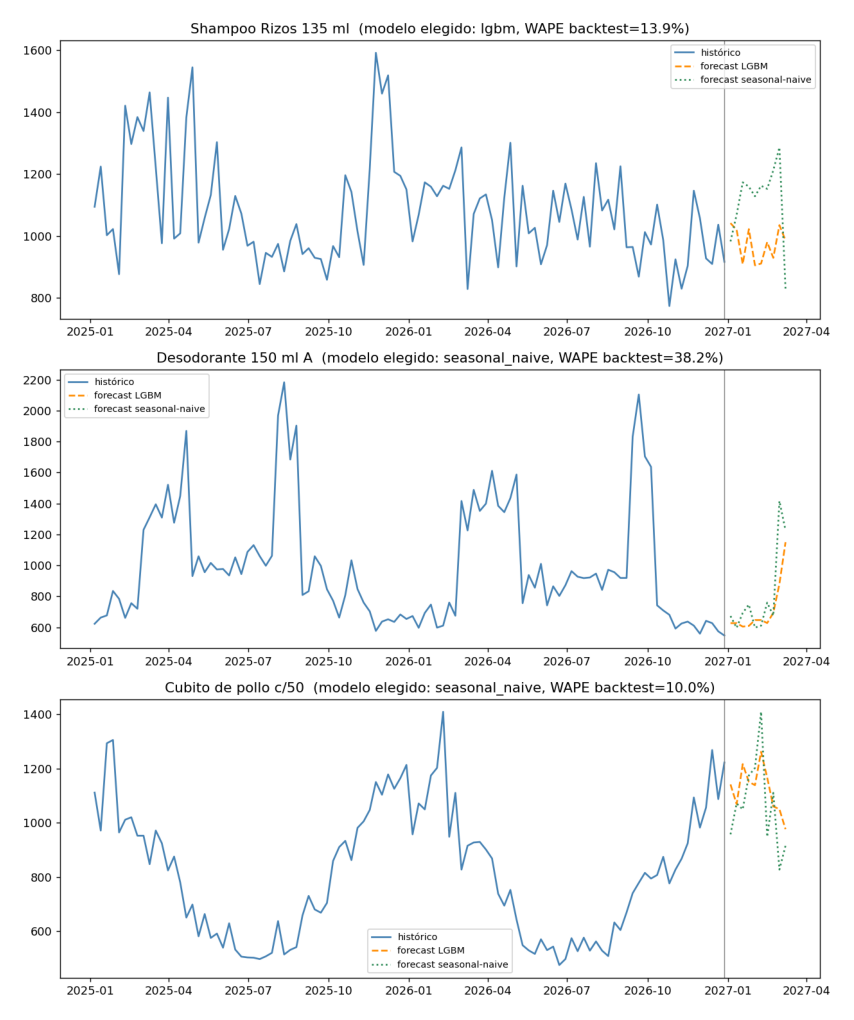

In [6]:
from matplotlib import image as mpimg
img = mpimg.imread("report/reto_a_forecasts.png")
plt.figure(figsize=(11,13))
plt.imshow(img)
plt.axis('off')
plt.show()

**Nota de negocio:** este forecast proyecta demanda "de negocio normal" — **no asume promociones futuras específicas**, porque no sabemos con certeza cuáles se van a activar el próximo trimestre. Si el equipo comercial ya tiene definido un combo para las próximas semanas, el forecast debe ajustarse sumando el uplift esperado (ver Reto C) sobre esta base.

---
## Reto B — Elasticidad de precio y simulador

**SKU elegido:** *Antitranspirante 150 ml C* — el de mayor variación de precio observada (coeficiente de variación de precio efectivo ≈ 0.10, el más alto de los 6 SKUs), lo que da mejor identificación estadística de la elasticidad.

**Metodología:**
1. Panel semanal de precio efectivo ponderado por volumen (`amount / qty`, excluyendo tickets cancelados y de regalo) y cantidad vendida.
2. Regresión log-log: `log(qty) ~ log(price) + tendencia + dummies de mes`, con errores robustos a heterocedasticidad (HC1). Los dummies de mes controlan estacionalidad para que el coeficiente de precio no capture, por casualidad, que las promociones coinciden con meses de alta demanda.
3. El coeficiente de `log(price)` **es** la elasticidad precio-demanda (interpretación directa: %Δcantidad por %Δprecio).

In [7]:
from elasticity import ELASTICITY_SKU, weekly_price_panel, fit_elasticity, make_simulator

panel = weekly_price_panel(df, ELASTICITY_SKU)
print(f"SKU: {ELASTICITY_SKU}  |  semanas: {len(panel)}  |  rango de precio observado: [{panel.price.min():.2f}, {panel.price.max():.2f}]")

model = fit_elasticity(panel)
print(model.summary())

SKU: Antitranspirante 150 ml C  |  semanas: 104  |  rango de precio observado: [46.36, 63.39]
                            OLS Regression Results                            
Dep. Variable:                    qty   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     161.0
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           2.40e-56
Time:                        19:37:26   Log-Likelihood:                 118.15
No. Observations:                 104   AIC:                            -208.3
Df Residuals:                      90   BIC:                            -171.3
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [8]:
elasticity = model.params['log_price']
print(f"Elasticidad precio-demanda estimada: {elasticity:.2f}")
print("(demanda altamente elástica: una baja de 1% en precio se asocia a un alza de ~3% en unidades, manteniendo estacionalidad y tendencia fijas)")

Elasticidad precio-demanda estimada: -2.98
(demanda altamente elástica: una baja de 1% en precio se asocia a un alza de ~3% en unidades, manteniendo estacionalidad y tendencia fijas)


### Simulador de precio

El simulador usa un modelo de elasticidad constante: `demanda(p) = demanda_ref × (p / precio_ref) ^ elasticidad`, anclado a la demanda promedio de las últimas 12 semanas (`demanda_ref`, `precio_ref`) para reflejar el nivel de negocio actual. A partir de ahí calcula ingreso y margen usando el costo unitario y margen fijo provistos por SKU.

**Solo se evalúa dentro del rango de precio históricamente observado** — no hay evidencia en los datos para proyectar fuera de ese rango, y un modelo log-log extrapola de forma no confiable (la elasticidad no tiene por qué mantenerse constante fuera del rango observado).

In [9]:
unit_cost_recent = df[(df.product_name == ELASTICITY_SKU) & (df.sell_in_quantity > 0)].tail(2000)['unit_cost'].median()
ref = panel.tail(12)
ref_price, ref_qty = ref['price'].mean(), ref['qty'].mean()
price_min, price_max = panel.price.min(), panel.price.max()

print(f"precio_ref={ref_price:.2f}  demanda_ref={ref_qty:.0f} u/sem  costo_unitario={unit_cost_recent:.2f}  rango=[{price_min:.2f}, {price_max:.2f}]")

sim = make_simulator(elasticity, ref_price, ref_qty, unit_cost_recent, price_min, price_max)

# Ejemplo de uso del simulador para 3 precios puntuales
sim([price_min, ref_price, price_max]).round(1)

precio_ref=63.34  demanda_ref=366 u/sem  costo_unitario=46.85  rango=[46.36, 63.39]


,price,demanda_esperada,ingreso,margen_abs,margen_pct,fuera_de_rango_observado
0,46.4,925.9,42929.9,-446.6,-0.0,False
1,63.3,365.8,23164.9,6030.9,0.3,False
2,63.4,364.9,23127.4,6035.1,0.3,False


In [10]:
grid = pd.read_csv("data/reto_b_simulation_grid.csv")
best_margin = grid.loc[grid.margen_abs.idxmax()]
best_revenue = grid.loc[grid.ingreso.idxmax()]
print("Precio que maximiza MARGEN $ dentro del rango observado:")
print(best_margin)
print("\nPrecio que maximiza INGRESO $ dentro del rango observado:")
print(best_revenue)

# Chequeo teórico: óptimo de margen sin restricción de rango, para un monopolista con elasticidad constante,
# es p* = costo * e / (e + 1). Lo calculamos solo como referencia -- NO es una recomendación,
# porque cae fuera del rango observado y no hay evidencia que lo respalde.
p_star_unconstrained = unit_cost_recent * elasticity / (elasticity + 1)
print(f"\n(referencia) óptimo teórico sin restricción de rango: {p_star_unconstrained:.2f} -> "
      f"cae {'DENTRO' if price_min<=p_star_unconstrained<=price_max else 'FUERA'} del rango observado [{price_min:.2f}, {price_max:.2f}]")

Precio que maximiza MARGEN $ dentro del rango observado:
price                         63.387165
demanda_esperada             364.859205
ingreso                     23127.39076
margen_abs                  6035.141709
margen_pct                     0.260952
fuera_de_rango_observado          False
Name: 39, dtype: object

Precio que maximiza INGRESO $ dentro del rango observado:
price                          46.363781
demanda_esperada              925.937071
ingreso                     42929.943919
margen_abs                   -446.643002
margen_pct                     -0.010404
fuera_de_rango_observado           False
Name: 0, dtype: object

(referencia) óptimo teórico sin restricción de rango: 70.53 -> cae FUERA del rango observado [46.36, 63.39]


In [11]:
img = mpimg.imread("report/reto_b_simulador.png")
plt.figure(figsize=(9,6))
plt.imshow(img)
plt.axis('off')
plt.show()

**Recomendación:** dentro del rango de precios observado, el margen $ se maximiza en el extremo superior (precio de lista, sin descuento adicional) — la demanda no reacciona lo suficiente como para que bajar el precio compense la pérdida de margen unitario. El óptimo teórico sin restricción de rango cae **fuera** de lo observado, así que no lo usamos como recomendación (no hay evidencia de cómo se comportaría la demanda ahí). **Recomendación práctica: no profundizar más el descuento de este SKU; si se busca ganar volumen, es mejor palanca una promoción tipo combo con mecánica distinta (bundle, regalo) que preserve el precio unitario.**

**Riesgos / supuestos que limitan esta estimación:**
- Es una relación **observacional**, no un experimento controlado — el precio no varió de forma aleatoria (varía por combos planeados), así que la elasticidad puede confundirse con otros factores correlacionados con el momento en que se lanzan los combos.
- El número de condición alto en la regresión (ver *Notes* del summary) sugiere colinealidad entre estacionalidad y momento de las promociones — el modelo puede estar repartiendo el efecto entre `log_price` y los dummies de mes de forma imprecisa.
- El costo unitario se asume constante en el horizonte de simulación (mediana reciente); si el costo cambia, cambia también el margen óptimo.
- Elasticidad constante es una simplificación — en la práctica la sensibilidad al precio puede cambiar de forma en distintos tramos (ej. cerca del costo, cerca del precio de lista).

---
## Reto C — Uplift promocional

**Metodología:** para cada combo, se ajusta un modelo estacional (tendencia + dummies de mes sobre `log(qty)`) **usando solo semanas sin promoción** de ese SKU. Ese modelo se usa para predecir la demanda contrafactual ("qué hubiera vendido sin la promo") durante la ventana del combo. El uplift es la diferencia entre la venta real y esa contrafactual.

Esto es más robusto que comparar contra el mismo periodo del año anterior (algunos combos no tienen equivalente exacto un año atrás) y más robusto que comparar contra semanas adyacentes (que pueden tener su propia estacionalidad).

Se calculó el uplift para **las 19 promociones** del histórico (no solo 2) para poder elegir con evidencia cuál replicar y cuál no — el detalle de las 2 destacadas está abajo; la tabla completa está en `data/reto_c_all_combos.csv`.

In [12]:
from uplift import PROMOS, estimate_uplift

for p in PROMOS:
    res, wk, promo_weeks = estimate_uplift(df, p['sku'], p['id_combo'], p['nombre'])
    print(res)
    print()

{'sku': 'Antitranspirante 150 ml C', 'promo': 'Combo Verano 2', 'inicio': datetime.date(2026, 3, 2), 'fin': datetime.date(2026, 5, 10), 'semanas': 10, 'actual_units': 8122, 'baseline_units': 4202, 'incremental_units': 3920, 'uplift_pct': np.float64(93.3), 'ref_price': np.float64(58.43), 'actual_revenue': 414898, 'incremental_revenue': 169362, 'incremental_margin': -14267, 'margin_pct_of_incr_rev': np.float64(-8.4)}



{'sku': 'Cubito de pollo c/50', 'promo': 'Combo Invierno 2', 'inicio': datetime.date(2026, 7, 6), 'fin': datetime.date(2026, 8, 9), 'semanas': 5, 'actual_units': 2766, 'baseline_units': 2552, 'incremental_units': 214, 'uplift_pct': np.float64(8.4), 'ref_price': np.float64(196.27), 'actual_revenue': 501758, 'incremental_revenue': 871, 'incremental_margin': -32771, 'margin_pct_of_incr_rev': np.float64(-3763.2)}



In [13]:
img = mpimg.imread("report/reto_c_uplift.png")
plt.figure(figsize=(11,9))
plt.imshow(img)
plt.axis('off')
plt.show()

### Las 19 promociones, ordenadas por margen incremental ($)

In [14]:
all_combos = pd.read_csv("data/reto_c_all_combos.csv").sort_values('incremental_margin', ascending=False)
all_combos[['sku','promo','semanas','actual_units','incremental_units','uplift_pct','incremental_revenue','incremental_margin']]

,sku,promo,semanas,actual_units,incremental_units,uplift_pct,incremental_revenue,incremental_margin
13,Shampoo 180ml Verde,Combo Verde 2,5,1463,215,17.2,1816,-1000
1,Shampoo 180ml Verde,Combo Verde Chico,4,1208,120,11.0,-840,-2414
11,Shampoo Rizos 135 ml,Combo Cabello 3,6,6643,970,17.1,10993,-3894
17,Shampoo 135 ml Azul,Combo Azul Otoño,4,3532,441,14.3,899,-5751
3,Shampoo 135 ml Azul,Combo Azul Primavera,5,3979,110,2.9,-7896,-9561
14,Shampoo Rizos 135 ml,Combo Cabello Sano,5,6996,1957,38.8,17498,-12549
16,Shampoo Rizos 135 ml,Combo Regreso a Clases Cabello,6,8126,1411,21.0,8262,-13398
4,Antitranspirante 150 ml C,Combo Verano 2,10,8122,3920,93.3,169362,-14267
6,Antitranspirante 150 ml C,Combo Cierre Trimestre,4,3306,1545,87.8,57602,-14791
7,Antitranspirante 150 ml C,Combo Verano Antitranspirante,8,5994,2522,72.6,93535,-24597


**Hallazgo principal:** bajo esta metodología, **las 19 promociones del histórico muestran margen incremental negativo** — el uplift en unidades nunca compensa por completo la pérdida de margen unitario por el descuento, incluso contando la canibalización de unidades que se hubieran vendido de todas formas. Este hallazgo es consistente con la elasticidad estimada en el Reto B (≈ -3.0 para Antitranspirante): validamos cruzado — para "Combo Verano 2" (descuento promedio ~16%), el modelo de elasticidad predice un alza de demanda de ~+69%, cercana al +93% observado con el modelo de uplift; ambas metodologías, independientes entre sí, apuntan en la misma dirección.

**Promoción que SÍ recomendaría replicar (con ajuste): "Combo Verano 2" — Antitranspirante 150 ml C.**
Genera el mayor uplift de unidades de todo el histórico (+93%, +3,920 u.) y, aunque su margen incremental es negativo (-$14,267), es el **más leve en términos relativos** (-8.4% del ingreso incremental) de las promociones de alto volumen. Es la promoción con mejor relación construcción-de-volumen vs. costo-de-margen. Con el simulador del Reto B como guía, bajar la profundidad del descuento 3-5 puntos porcentuales probablemente la lleva a margen positivo sin perder la mayor parte del volumen (dado que el precio actual está lejos del óptimo teórico de margen).

**Promoción que NO recomendaría replicar: "Combo Invierno 2" — Cubito de pollo c/50.**
Es el peor caso de todo el histórico: apenas +8.4% de uplift en unidades (214 unidades) pero -$32,771 de margen — casi toda la venta durante la ventana promocional habría ocurrido de cualquier forma (altísima canibalización, cliente ya compraba este producto de forma recurrente). Es, en la práctica, un descuento regalado sin respuesta de demanda.

---
## Conclusiones y recomendaciones de negocio

Ver documento adjunto `report/VEMIO_metodologia_hallazgos.docx` para el resumen ejecutivo de 1-2 páginas con supuestos, metodología y trade-offs, y las 3-5 recomendaciones de negocio en lenguaje no técnico.